# EGX Stock Market — Cleaning & Analysis

**Dataset:** EGX companies, daily trading records, and market indices from the Egyptian Exchange.

**Made by : Abdel-Rahman Mahmoud Atai - 202500699 , Omar Saeed Abouzeed - 202500427**
**Section 6**

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

# 1. Load Data

In [7]:
df  = pd.read_csv('raw.csv')
df2 = pd.read_csv('stock_data.csv')

In [8]:
df.head(10)

,Date,Company,Symbol,MarketCap,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
0,2025-06-01 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,81.750000,82.239998,81.160004,81.160004,424708,0.0,0.0,0.0
1,2025-06-02 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,81.160004,81.879997,80.010002,80.559998,77620,0.0,0.0,0.0
2,2025-06-03 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,80.559998,80.980003,79.959999,80.110001,136590,0.0,0.0,0.0
3,2025-06-04 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,80.110001,80.650002,79.910004,80.500000,154041,0.0,0.0,0.0
4,2025-06-10 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,80.500000,81.209999,80.019997,80.750000,69382,0.0,0.0,0.0
5,2025-06-11 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,80.750000,81.209999,80.000000,80.209999,92666,0.0,0.0,0.0
6,2025-06-12 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,80.209999,80.599998,78.500000,78.510002,528845,0.0,0.0,0.0
7,2025-06-15 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,78.510002,77.699997,74.500000,76.599998,163295,0.0,0.0,0.0
8,2025-06-16 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,76.599998,78.000000,76.599998,77.070000,181288,0.0,0.0,0.0
9,2025-06-17 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,77.070000,78.510002,75.500000,75.959999,82074,0.0,0.0,0.0


In [9]:
df2.head()

,Company,Sector,Price,1D,YTD,M.Cap,Date
0,Company,Sector,Price,1D,YTD,M.Cap,Date
1,Abu Dhabi Islamic Bank Egypt,Financials,39.89,-2.47%,+33.41%,47.86,24/03
2,Abu Qir Fertilizers,Basic Materials,94.00,+8.05%,+84.31%,118.61,24/03
3,Acrow Misr,Industrials,127.52,-,+4.64%,7.02,24/03
4,Advanced Pharmaceutical Packaging Co.,Industrials,2.33,-,-,0,24/03


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4640 entries, 0 to 4639
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           4640 non-null   object 
 1   Company        4640 non-null   object 
 2   Symbol         4640 non-null   object 
 3   MarketCap      4640 non-null   int64  
 4   Open           4640 non-null   float64
 5   High           4640 non-null   float64
 6   Low            4640 non-null   float64
 7   Close          4640 non-null   float64
 8   Volume         4640 non-null   int64  
 9   Dividends      4640 non-null   float64
 10  Stock Splits   4640 non-null   float64
 11  Capital Gains  4640 non-null   float64
dtypes: float64(7), int64(2), object(3)
memory usage: 435.1+ KB


# 2. Cleaning & Formatting

## 2.1 Dataset 1

In [11]:
df.describe()

,MarketCap,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
count,4.640000e+03,4640.000000,4640.000000,4640.000000,4640.000000,4.640000e+03,4640.000000,4640.000000,4640.0
mean,3.742301e+10,28.017820,28.487500,27.719858,28.068615,5.021843e+06,0.001872,0.002922,0.0
std,5.302482e+10,27.041865,27.608807,26.775546,27.153059,1.631203e+07,0.090397,0.068099,0.0
min,9.164430e+08,0.644000,0.649000,0.627000,0.644000,0.000000e+00,0.000000,0.000000,0.0
25%,8.262643e+09,8.180000,8.300000,8.097500,8.187500,3.041320e+05,0.000000,0.000000,0.0
50%,1.932572e+10,19.304999,19.570000,19.135000,19.304999,9.432640e+05,0.000000,0.000000,0.0
75%,4.297567e+10,41.806617,42.607500,41.000000,41.955819,2.833176e+06,0.000000,0.000000,0.0
max,2.683270e+11,161.320007,170.979996,159.009995,170.979996,5.561549e+08,6.000000,3.000000,0.0


In [12]:
df = df.drop(['Capital Gains', 'Dividends', 'Stock Splits'], axis=1)
df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'], utc=True, errors='coerce')
df['Date'] = df['Date'].dt.tz_convert(None)

df.isna().sum()

,0
Date,0
Company,0
Symbol,0
MarketCap,0
Open,0
High,0
Low,0
Close,0
Volume,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4640 entries, 0 to 4639
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4640 non-null   datetime64[ns]
 1   Company    4640 non-null   object        
 2   Symbol     4640 non-null   object        
 3   MarketCap  4640 non-null   int64         
 4   Open       4640 non-null   float64       
 5   High       4640 non-null   float64       
 6   Low        4640 non-null   float64       
 7   Close      4640 non-null   float64       
 8   Volume     4640 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 326.4+ KB


## 2.2 Dataset 2

In [14]:
df2.describe()

,Company,Sector,Price,1D,YTD,M.Cap,Date
count,290,306,306,306,301,284,284
unique,288,33,293,171,217,207,15
top,Misr Chemical Industries,Financials,1.00,-,-,0,24/03
freq,2,90,6,101,65,39,241


In [15]:
SECTORS = [
    'Financials', 'Basic Materials', 'Industrials', 'Consumer Goods',
    'Consumer Services', 'Technology', 'Health Care', 'Utilities', 'Telecom', 'Oil & Gas'
]

df2 = df2[df2['Sector'].isin(SECTORS)].copy()
df2 = df2.dropna(subset=['Company', 'Sector']).reset_index(drop=True)

for col in ['Price', 'M.Cap', '1D', 'YTD']:
    df2[col] = pd.to_numeric(
        df2[col].astype(str).str.replace('%','',regex=False)
                            .str.replace('+','',regex=False)
                            .str.replace(',','',regex=False)
                            .str.strip(), errors='coerce')

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  283 non-null    object 
 1   Sector   283 non-null    object 
 2   Price    282 non-null    float64
 3   1D       182 non-null    float64
 4   YTD      217 non-null    float64
 5   M.Cap    282 non-null    float64
 6   Date     282 non-null    object 
dtypes: float64(4), object(3)
memory usage: 15.6+ KB


## 2.3 Standardise Company Names & Merge

Many companies appear in both datasets under slightly different names
(e.g. `'Fawry'` vs `'Fawry for Banking Technology and Electronic Payment'`).
Without fixing this, those companies get no sector assignment after the merge.

We map every mismatched name in `df` to its counterpart in `df2`.

In [16]:
unmatched = set(df['Company'].unique()) - set(df2['Company'].unique())
print(sorted(unmatched))

['Abu Kir Fertilizers', 'Alexandria Container & Cargo Handling', 'Alexandria Mineral Oils', 'CIB Egypt', 'Cairo Poultry (Koki)', 'Commercial International Bank (CIB)', 'Egyptian Electrical Cables', 'El Sewedy Electric', 'Fawry', 'Hassan Allam Holding', 'Misr Capital', 'Modern Furniture', 'Orascom Construction', 'Orascom Telecom Media & Technology', 'Palm Hills Developments', 'Raya Holding', 'Talaat Moustafa Group', 'Unit Investments']


In [17]:
NAME_MAP = {
    'Abu Kir Fertilizers':                   'Abu Qir Fertilizers',
    'Alexandria Container & Cargo Handling': 'Alexandria Containers And Goods',
    'Alexandria Mineral Oils':               'Alexandria Mineral Oils Company',
    'Cairo Poultry (Koki)':                  'Cairo Poultry',
    'Commercial International Bank (CIB)':   'Commercial International Bank (Egypt)',
    'Egyptian Electrical Cables':            'Electro Cable Egypt Company',
    'El Sewedy Electric':                    'El Sewedy Electric Company',
    'Fawry':                                 'Fawry for Banking Technology and Electronic Payment',
    'Misr Capital':                          'Misr Financial Investments',
    'Orascom Construction':                  'Orascom Construction Industries',
    'Orascom Telecom Media & Technology':    'Global Telecom Holding',
    'Palm Hills Developments':               'Palm Hills Development Company',
    'Raya Holding':                          'Raya Holding for Financial Investments',
    'Talaat Moustafa Group':                 'TMG Holding',
}
df['Company'] = df['Company'].replace(NAME_MAP)


# 3. Processing The Data

**Formulas:**

- Range = (High − Low) / Close
- Period Return (%) = [(Close − Open) / Open] × 100
- Price vs 365-High/Low (%) = [(Close − High/Low₃₆₅) / High/Low₃₆₅] × 100
- Portfolio Value = start × ∏(1 + rₜ)
- Total Gain = Portfolio Value − start

In [18]:
df['Price_Range']   = (df['High'] - df['Low']) / df['Close']
df['Period_Return'] = ((df['Close'] - df['Open']) / df['Open']) * 100

df = df.sort_values(['Company', 'Date']).set_index('Date')

# min_periods=1 so early rows aren't dropped just because the window isn't full yet
# transform keeps the result aligned with the original index (needed for groupby)
df['High_365'] = df.groupby('Company')['High'].transform(
    lambda x: x.rolling('365D', min_periods=1).max()
)
df['Low_365'] = df.groupby('Company')['Low'].transform(
    lambda x: x.rolling('365D', min_periods=1).min()
)

df['Price_vs_365_High'] = ((df['Close'] - df['High_365']) / df['High_365']) * 100
df['Price_vs_365_Low'] = ((df['Close'] - df['Low_365']) / df['Low_365']) * 100

df = df.reset_index()

df = df.sort_values(['Company', 'Date']).reset_index(drop=True)

df['Daily_Return'] = df.groupby('Company')['Close'].pct_change()

start = 10_000
df['Portfolio_Value'] = df.groupby('Company')['Daily_Return'].transform(
    lambda r: start * (1 + r.fillna(0)).cumprod()
)
df['Total_Gain'] = df['Portfolio_Value'] - start

df

,Date,Company,Symbol,MarketCap,Open,High,Low,Close,Volume,Price_Range,Period_Return,High_365,Low_365,Price_vs_365_High,Price_vs_365_Low,Daily_Return,Portfolio_Value,Total_Gain
0,2025-05-31 21:00:00,Abu Qir Fertilizers,ABUK.CA,73592594432,42.918101,43.379968,42.802633,42.989159,583557,0.013430,0.165567,43.379968,42.802633,-0.900898,0.435781,NaN,10000.000000,0.000000
1,2025-06-01 21:00:00,Abu Qir Fertilizers,ABUK.CA,73592594432,42.989157,43.921773,43.077977,43.522079,648049,0.019388,1.239666,43.921773,42.802633,-0.910012,1.680847,0.012397,10123.966333,123.966333
2,2025-06-02 21:00:00,Abu Qir Fertilizers,ABUK.CA,73592594432,43.522078,43.939536,43.548723,43.602016,379774,0.008963,0.183674,43.939536,42.802633,-0.768144,1.867604,0.001837,10142.561017,142.561017
3,2025-06-03 21:00:00,Abu Qir Fertilizers,ABUK.CA,73592594432,43.602020,44.312584,43.495436,44.312584,592659,0.018441,1.629658,44.312584,42.802633,0.000000,3.527706,0.016297,10307.850941,307.850941
4,2025-06-09 21:00:00,Abu Qir Fertilizers,ABUK.CA,73592594432,44.312582,45.174142,44.339227,45.085320,1118897,0.018519,1.743834,45.174142,42.802633,-0.196623,5.333052,0.017438,10487.602213,487.602213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4635,2025-12-24 22:00:00,Unit Investments,UNIT.CA,1450209408,10.930000,11.300000,10.950000,11.220000,282815,0.031194,2.653248,12.000000,6.850000,-6.499998,63.795627,0.026532,14514.877412,4514.877412
4636,2025-12-27 22:00:00,Unit Investments,UNIT.CA,1450209408,11.220000,11.350000,11.000000,11.160000,152068,0.031362,-0.534763,12.000000,6.850000,-7.000001,62.919708,-0.005348,14437.257206,4437.257206
4637,2025-12-28 22:00:00,Unit Investments,UNIT.CA,1450209408,11.160000,11.250000,10.600000,11.060000,244465,0.058770,-0.896052,12.000000,6.850000,-7.833330,61.459862,-0.008961,14307.891840,4307.891840
4638,2025-12-29 22:00:00,Unit Investments,UNIT.CA,1450209408,11.060000,11.180000,10.760000,10.940000,159383,0.038391,-1.084999,12.000000,6.850000,-8.833337,59.708025,-0.010850,14152.651427,4152.651427


# 4. Visualization

In [19]:
sector_map = df2.drop_duplicates('Company').set_index('Company')['Sector'].to_dict()
df['Sector'] = df['Company'].map(sector_map)

sector_colors = {
    'Financials':        '#e74c3c',
    'Basic Materials':   "#4a2525",
    'Industrials':       '#2ecc71',
    'Consumer Goods':    '#f39c12',
    'Consumer Services': '#9b59b6',
    'Technology':        '#1abc9c',
    'Health Care':       '#e91e63',
    'Utilities':         '#00bcd4',
    'Telecom':           "#3122ff",
    'Oil & Gas':         "#080808"
}


print("Companies:", df['Company'].nunique())
print("Date range:", df['Date'].min().date(), ":", df['Date'].max().date())

Companies: 32
Date range: 2025-05-31 : 2025-12-30


---
## 4.1 Sector Network

Nodes: 28
Edges: 66


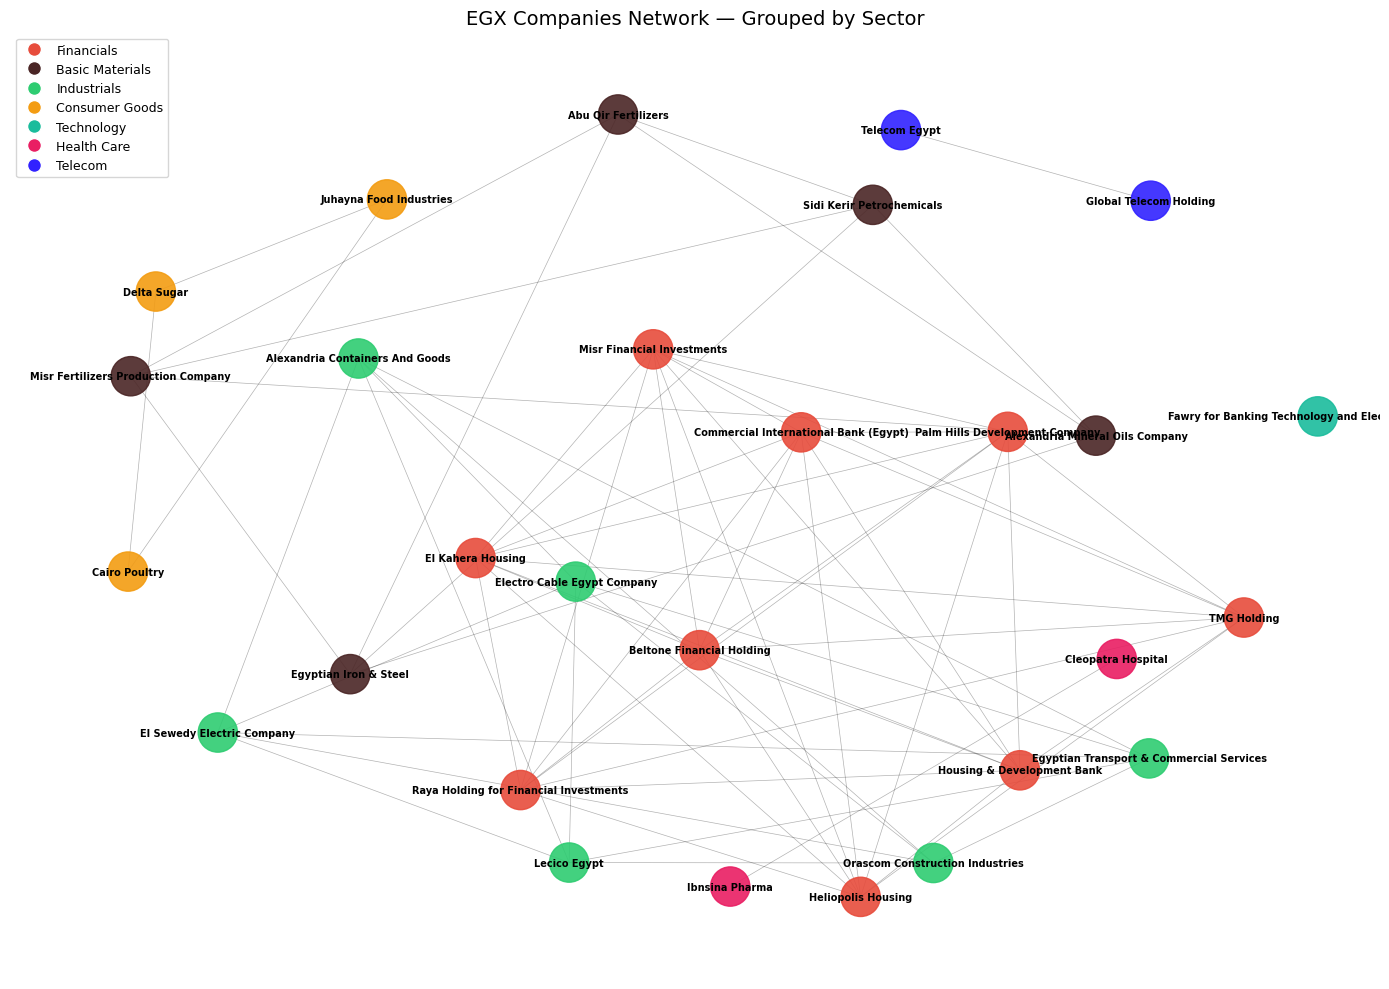

In [20]:
G_sector = nx.Graph()

sectors = df['Sector'].dropna().unique()
for sector in sectors:
    companies = df[df['Sector'] == sector]['Company'].unique()
    for company in companies:
        G_sector.add_node(company, sector=sector)
    for i in range(len(companies)):
        for j in range(i + 1, len(companies)):
            G_sector.add_edge(companies[i], companies[j])

print(f'Nodes: {G_sector.number_of_nodes()}')
print(f'Edges: {G_sector.number_of_edges()}')

node_colors = [sector_colors.get(G_sector.nodes[n].get('sector', ''), '#95a5a6') for n in G_sector.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G_sector, k=2, iterations=50, seed=42)

nx.draw_networkx_nodes(G_sector,  pos, ax=ax, node_color=node_colors, node_size=800, alpha=0.9)
nx.draw_networkx_edges(G_sector,  pos, ax=ax, edge_color='#000000', width=0.5, alpha=0.3)
nx.draw_networkx_labels(G_sector, pos, ax=ax, font_size=7, font_weight='bold')

legend_list = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=s)
    for s, c in sector_colors.items() if s in df['Sector'].dropna().unique()
]
ax.legend(handles=legend_list, loc='upper left', fontsize=9)
ax.set_title('EGX Companies Network — Grouped by Sector', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

In [21]:
degree_centrality = nx.degree_centrality(G_sector)

top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top nodes by degree centrality:")
print(top_degree)

Top nodes by degree centrality:
[('Beltone Financial Holding', 0.2962962962962963), ('Commercial International Bank (Egypt)', 0.2962962962962963), ('El Kahera Housing', 0.2962962962962963), ('Heliopolis Housing', 0.2962962962962963), ('Housing & Development Bank', 0.2962962962962963)]


In [22]:
betweenness_centrality = nx.betweenness_centrality(G_sector)

top_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top nodes by betweenness centrality:")
print(top_betweenness)

Top nodes by betweenness centrality:
[('Abu Qir Fertilizers', 0.0), ('Alexandria Mineral Oils Company', 0.0), ('Egyptian Iron & Steel', 0.0), ('Misr Fertilizers Production Company', 0.0), ('Sidi Kerir Petrochemicals', 0.0)]


---
## 4.2  Sector Portfolio Growth

**Formula Applied:**
    Portfolio Value = 10,000 × ∏(1 + Daily_Return)

                 Daily_Return  YTD_Return
Sector                                   
Industrials         -0.000556   13.429706
Basic Materials      0.000110    8.291429
Consumer Goods       0.000244   -4.469750
Financials           0.001870   -0.232639
Telecom              0.002349   35.228000
Technology           0.002580    1.715714
Health Care          0.002758    0.167778


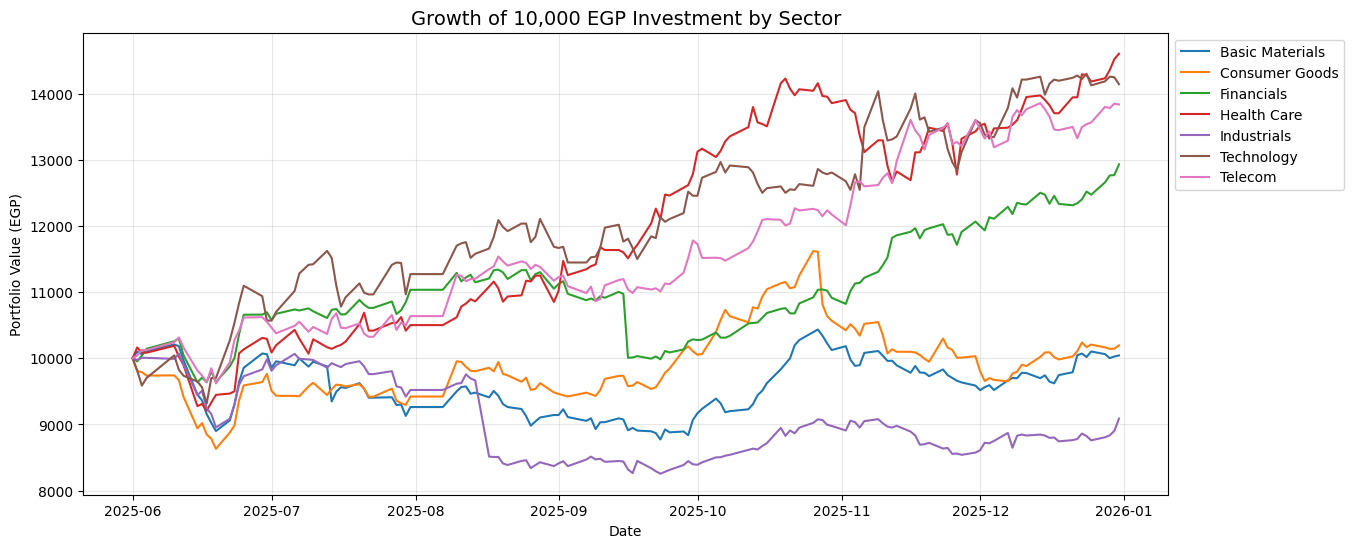

In [23]:
# Calculate average daily return and YTD by sector
sector_daily = df.groupby('Sector')['Daily_Return'].mean()
sector_ytd = df2.groupby('Sector')['YTD'].mean()

# Combine into one DataFrame
comparison = pd.DataFrame({'Daily_Return': sector_daily, 'YTD_Return': sector_ytd})

comparison = comparison.dropna().sort_values('Daily_Return')
print(comparison)

sector_stats = df.groupby('Sector').agg({ 'Daily_Return': ['mean', 'std'],'Volume': 'sum'})

sector_stats.columns = ['Avg_Daily_Return', 'Volatility', 'Total_Volume']

sector_stats = sector_stats.reset_index()

sector_mcap = df2.groupby('Sector')['M.Cap'].sum().reset_index()
sector_stats = pd.merge(sector_stats, sector_mcap, on='Sector')


sector_daily_returns = df.groupby(['Date', 'Sector'])['Daily_Return'].mean().reset_index()

sectors = sector_daily_returns['Sector'].unique()

plt.figure(figsize=(14, 6))

initial_investment = 10_000

for sector in sectors:

    # Filter data for this sector only
    sector_data = sector_daily_returns[sector_daily_returns['Sector'] == sector].copy()
    sector_data = sector_data.sort_values('Date')

    sector_data['Daily_Return'] = sector_data['Daily_Return'].fillna(0)


    sector_data['Cumulative'] = initial_investment * (1 + sector_data['Daily_Return']).cumprod()



    plt.plot(sector_data['Date'], sector_data['Cumulative'], label=sector)

plt.title(f'Growth of {initial_investment:,} EGP Investment by Sector', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Portfolio Value (EGP)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.show()


---
## 4.3  Annualised Volatility - التقلب السنوي

Volatility measures the dispersion of daily returns. Annualising scales daily standard deviation to a yearly figure using the square-root-of-time rule:
    Ann_Volatility = Std_Daily_Return × √252

where 252 is the conventional number of trading days per year.

In [24]:
TRADING_DAYS = 252

risk = df.groupby('Company')['Daily_Return'].agg(Mean_Daily_Return='mean',Std_Daily_Return='std').dropna()

risk['Ann_Return'] = risk['Mean_Daily_Return'] * TRADING_DAYS
risk['Ann_Volatility'] = risk['Std_Daily_Return']  * np.sqrt(TRADING_DAYS)

risk = risk.reset_index()
risk['Sector'] = risk['Company'].map(sector_map)

print(risk[['Company', 'Ann_Return', 'Ann_Volatility', 'Sector']].sort_values('Ann_Volatility', ascending=False).to_string(index=False))

                                            Company  Ann_Return  Ann_Volatility          Sector
                    Orascom Construction Industries   -1.172688        1.033702     Industrials
                                 Heliopolis Housing   -1.174127        0.935314      Financials
                         Misr Financial Investments    2.727015        0.712630      Financials
                              Egyptian Iron & Steel   -0.010779        0.559722 Basic Materials
                Misr Fertilizers Production Company   -0.254417        0.440534 Basic Materials
                                      Cairo Poultry    0.377855        0.432692  Consumer Goods
             Raya Holding for Financial Investments    0.505000        0.408257      Financials
                                   Modern Furniture   -0.104670        0.407772             NaN
                          Beltone Financial Holding    0.260173        0.392941      Financials
                            Juhayna Food

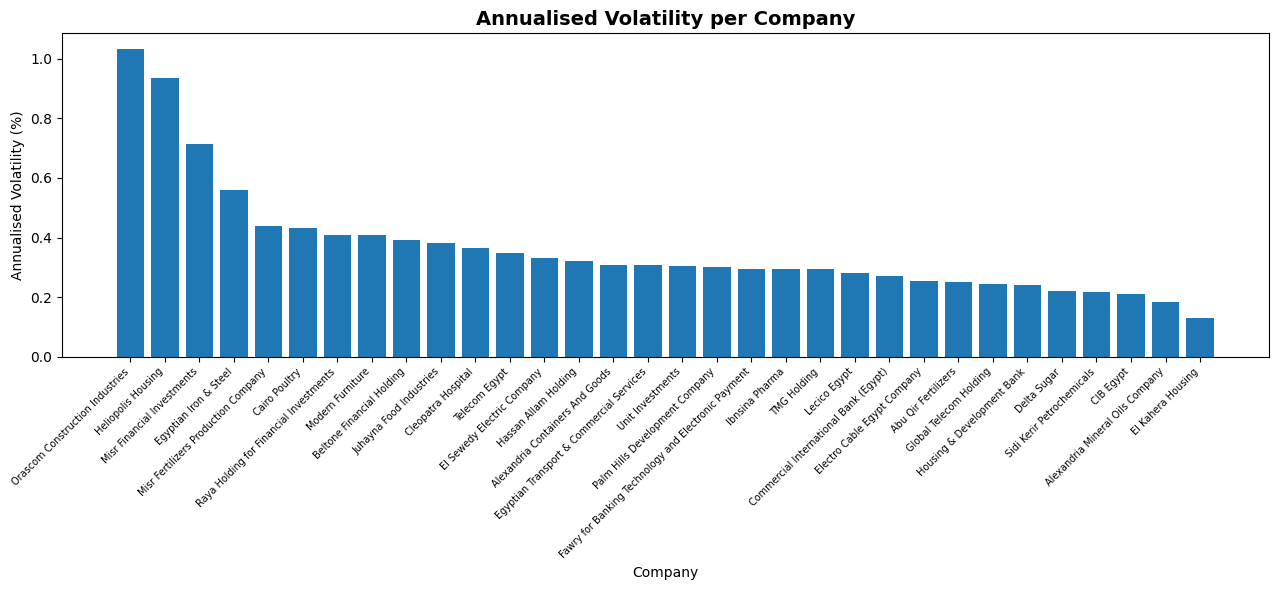

In [25]:
fig, ax = plt.subplots(figsize=(13, 6))

risk_sorted = risk.sort_values('Ann_Volatility', ascending=False)

ax.bar(risk_sorted['Company'], risk_sorted['Ann_Volatility'])

ax.set_title('Annualised Volatility per Company', fontsize=14, fontweight='bold')
ax.set_xlabel('Company')
ax.set_ylabel('Annualised Volatility (%)')

plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

---
## 4.4 Rolling 30-Day Volatility
**Formal used : Rolling Volatility (%) = std(Daily_Returns, 30-day window) × √252 × 100**

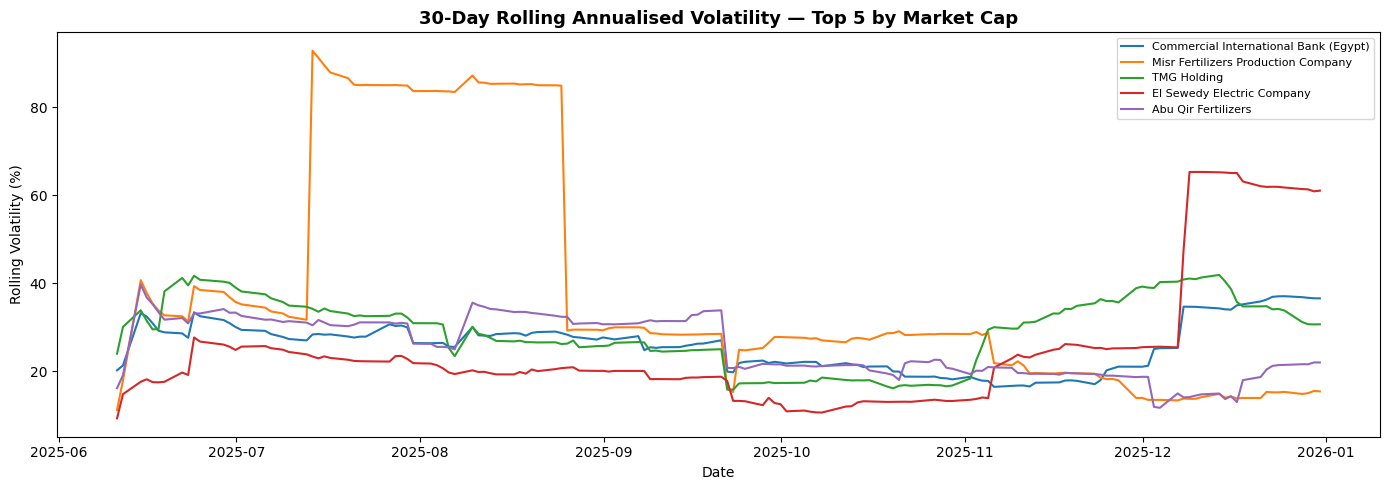

In [26]:
# Get top 5 companies by market cap
top5 = df.groupby('Company')['MarketCap'].mean().nlargest(5).index.tolist()

fig, ax = plt.subplots(figsize=(14, 5))

for company in top5:
    # Filter data for this company
    company_data = df[df['Company'] == company].copy()
    company_data = company_data.sort_values('Date')
    company_data = company_data.set_index('Date')

    # Calculate 30-day rolling volatility
    rolling_vol = company_data['Daily_Return'].rolling(window=30, min_periods=5).std()

    # Annualize the volatility
    rolling_vol_annual = rolling_vol * np.sqrt(TRADING_DAYS)

    rolling_vol_pct = rolling_vol_annual * 100

    ax.plot(rolling_vol_pct.index, rolling_vol_pct, label=company)
ax.set_title('30-Day Rolling Annualised Volatility — Top 5 by Market Cap',  fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Volatility (%)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

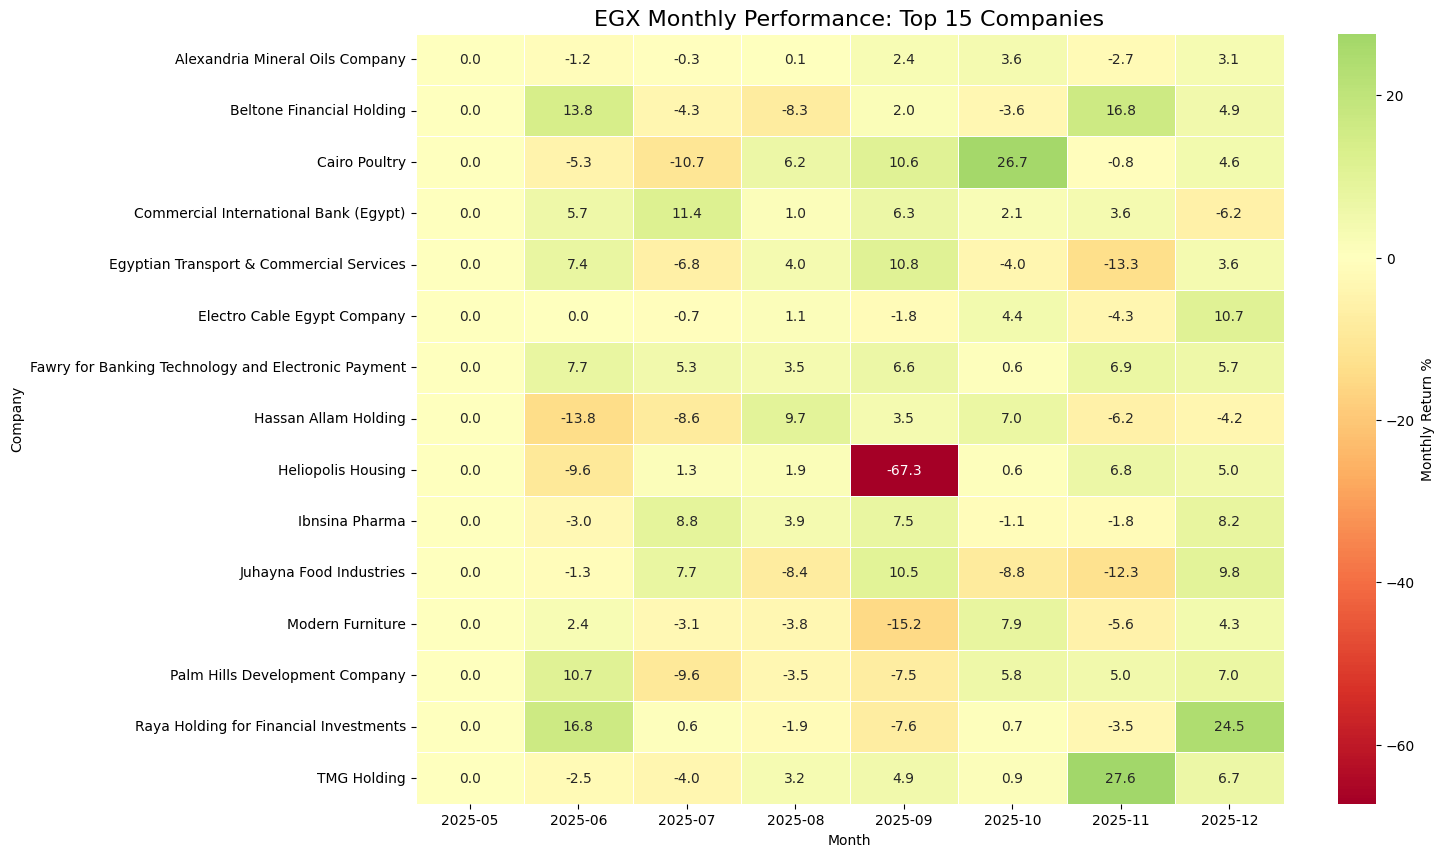

In [29]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

# 2. Calculate Monthly Return: (Last Close / First Close) - 1
monthly_perf = df.sort_values(['Company', 'Date']).groupby(['Company', 'Month'])['Close'].agg(['first', 'last'])
monthly_perf['Monthly_Return'] = (monthly_perf['last'] / monthly_perf['first'] - 1) * 100
monthly_perf = monthly_perf.reset_index()

# 3. Filter for readability (Top 15 companies by volume, last 12 months)
top_15 = df.groupby('Company')['Volume'].mean().nlargest(15).index
recent_12_months = sorted(monthly_perf['Month'].unique())[-12:]

plot_df = monthly_perf[
    (monthly_perf['Company'].isin(top_15)) &
    (monthly_perf['Month'].isin(recent_12_months))
].pivot(index='Company', columns='Month', values='Monthly_Return')

# 4. Create the Plot
plt.figure(figsize=(14, 10))
sns.heatmap(plot_df.astype(float), annot=True, fmt=".1f", cmap='RdYlGn', center=0,
            linewidths=.5, cbar_kws={'label': 'Monthly Return %'})

plt.title('EGX Monthly Performance: Top 15 Companies', fontsize=16)
plt.ylabel('Company')
plt.xlabel('Month')
plt.show()

New infos :

    The cumprod() method goes through the values in the DataFrame,
    from the top, row by row,
    multiplying the values with the value from the previous row,
    ending up with a DataFrame where the last row contains the product of all values for each column.

    The rolling() method goes through the values in the DataFrame,
    row by row (or time step by time step),
    collecting a fixed-size group of consecutive values called a window,
    and then applies a calculation (such as mean(), sum(), etc.) to that window.
    The window parameter decides how many consecutive values are included in each calculation.
    The min_periods parameter decides the minimum number of valid values needed in the window before a result is returned —
    if there are fewer valid values than min_periods, the result will be NaN.

